In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import streamlit as st

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df=pd.read_excel(r"D:\Local disk E\India_EV_Adoption\Dataset\Indian-EV.xlsx")

NameError: name 'pd' is not defined

In [ ]:
import os

print(os.getcwd())

e:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics


In [ ]:
state = pd.read_excel(r"E:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics\Dataset\Indian-EV.xlsx",sheet_name="State_Master")
state.head

<bound method NDFrame.head of    State_ID           State   Region  Population
0       S01      Tamil Nadu    South    76000000
1       S02       Karnataka    South    69000000
2       S03          Kerala    South    36000000
3       S04     Maharashtra     West   125000000
4       S05         Gujarat     West    72000000
5       S06           Delhi    North    33000000
6       S07   Uttar Pradesh    North   245000000
7       S08       Rajasthan    North    83000000
8       S09     West Bengal     East   101000000
9       S10          Odisha     East    47000000
10      S11       Telangana    South    41000000
11      S12  Madhya Pradesh  Central    90000000>

In [ ]:
fuel = pd.read_excel(r"E:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics\Dataset\Indian-EV.xlsx", sheet_name="Fuel_Prices")
ev = pd.read_excel(r"E:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics\Dataset\Indian-EV.xlsx", sheet_name="EV_Registrations")

charging = pd.read_excel(r"E:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics\Dataset\Indian-EV.xlsx", sheet_name="Charging_Stations")

renewable = pd.read_excel(r"E:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics\Dataset\Indian-EV.xlsx", sheet_name="Renewable_Energy")

subsidy =pd.read_excel(r"E:\India_EV_Adoption\India-s-Energy-Transition-EV-Adoption-Analytics\Dataset\Indian-EV.xlsx", sheet_name="Government_Subsidies")

In [ ]:
state.shape


(12, 4)

In [ ]:
state.head()

,State_ID,State,Region,Population
0,S01,Tamil Nadu,South,76000000
1,S02,Karnataka,South,69000000
2,S03,Kerala,South,36000000
3,S04,Maharashtra,West,125000000
4,S05,Gujarat,West,72000000


In [ ]:
state.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   State_ID    12 non-null     object
 1   State       12 non-null     object
 2   Region      12 non-null     object
 3   Population  12 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 516.0+ bytes


In [ ]:
state.isnull().sum()

State_ID      0
State         0
Region        0
Population    0
dtype: int64

In [ ]:
state.duplicated().sum()


np.int64(0)

In [ ]:
state["State_ID"].duplicated().sum()


np.int64(0)

In [ ]:
state["State"].duplicated().sum()


np.int64(0)

In [ ]:
state["State"] = state["State"].str.strip()


In [ ]:
state["State"] = state["State"].str.title()


In [ ]:
(state["Population"] <= 0).sum()

np.int64(0)

In [ ]:
ev.shape

(581, 8)

In [ ]:
ev.head

<bound method NDFrame.head of      Record_ID    Month State_ID   EV_2W  EV_3W   EV_4W  EV_Buses  Total_EV
0            1  2022-01      S01  3703.0  833.0  1125.0      29.0      5690
1            2  2022-02      S01     NaN  879.0  1155.0      33.0      2067
2            3  2022-03      S01  3824.0  903.0  1176.0      34.0      5937
3            4  2022-04      S01  3892.0  893.0  1262.0      30.0      6077
4            5  2022-05      S01  4032.0  933.0  1316.0      35.0      6316
..         ...      ...      ...     ...    ...     ...       ...       ...
576          1  2022-01      S01  3703.0  833.0  1125.0      29.0      5690
577          2  2022-02      S01     NaN  879.0  1155.0      33.0      2067
578          3  2022-03      S01  3824.0  903.0  1176.0      34.0      5937
579          4  2022-04      S01  3892.0  893.0  1262.0      30.0      6077
580          5  2022-05      S01  4032.0  933.0  1316.0      35.0      6316

[581 rows x 8 columns]>

In [ ]:
ev.isnull().sum()

Record_ID     0
Month         0
State_ID      0
EV_2W         8
EV_3W        13
EV_4W         7
EV_Buses     13
Total_EV      0
dtype: int64

In [ ]:
ev.fillna(0, inplace=True)


In [ ]:
ev["EV_2W"] = ev["EV_2W"].fillna(0)

print(ev["EV_2W"])


0      3703.0
1         0.0
2      3824.0
3      3892.0
4      4032.0
        ...  
576    3703.0
577       0.0
578    3824.0
579    3892.0
580    4032.0
Name: EV_2W, Length: 581, dtype: float64


In [ ]:
ev["EV_3W"] = ev["EV_3W"].fillna(0)
print(ev["EV_3W"])


0      833.0
1      879.0
2      903.0
3      893.0
4      933.0
       ...  
576    833.0
577    879.0
578    903.0
579    893.0
580    933.0
Name: EV_3W, Length: 581, dtype: float64


In [ ]:
ev["Month"] = pd.to_datetime(ev["Month"])
print(ev["Month"])


0     2022-01-01
1     2022-02-01
2     2022-03-01
3     2022-04-01
4     2022-05-01
         ...    
576   2022-01-01
577   2022-02-01
578   2022-03-01
579   2022-04-01
580   2022-05-01
Name: Month, Length: 581, dtype: datetime64[ns]


In [ ]:
median_value = ev["EV_Buses"].median()
ev["EV_Buses"] = ev["EV_Buses"].fillna(median_value)

print(ev["EV_Buses"])

0      29.0
1      33.0
2      34.0
3      30.0
4      35.0
       ... 
576    29.0
577    33.0
578    34.0
579    30.0
580    35.0
Name: EV_Buses, Length: 581, dtype: float64


In [ ]:
ev.isnull().sum()

Record_ID    0
Month        0
State_ID     0
EV_2W        0
EV_3W        0
EV_4W        0
EV_Buses     0
Total_EV     0
dtype: int64

In [ ]:
ev.duplicated().sum()
duplicates = ev[ev.duplicated()]
print(duplicates)



     Record_ID      Month State_ID   EV_2W  EV_3W   EV_4W  EV_Buses  Total_EV
576          1 2022-01-01      S01  3703.0  833.0  1125.0      29.0      5690
577          2 2022-02-01      S01     0.0  879.0  1155.0      33.0      2067
578          3 2022-03-01      S01  3824.0  903.0  1176.0      34.0      5937
579          4 2022-04-01      S01  3892.0  893.0  1262.0      30.0      6077
580          5 2022-05-01      S01  4032.0  933.0  1316.0      35.0      6316


In [ ]:
ev = ev.drop_duplicates()


In [ ]:
ev.duplicated().sum()

np.int64(0)

In [ ]:
fuel.shape


(576, 5)

In [ ]:
fuel.isnull().sum()


Record_ID       0
Month           0
State_ID        0
Petrol_Price    0
Diesel_Price    0
dtype: int64

In [ ]:
fuel["Month"] = pd.to_datetime(fuel["Month"])


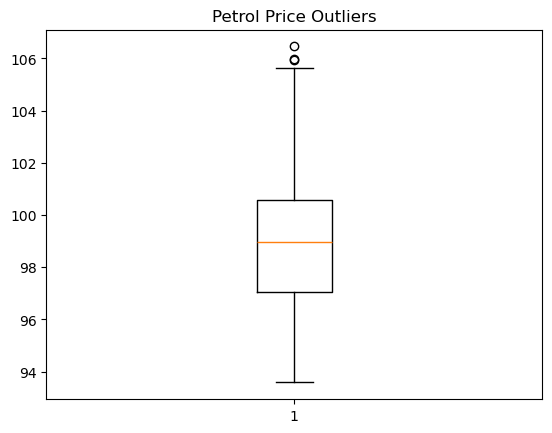

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(fuel["Petrol_Price"])
plt.title("Petrol Price Outliers")
plt.show()

In [ ]:
charging.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2439 entries, 0 to 2438
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Station_ID     2439 non-null   object 
 1   State_ID       2439 non-null   object 
 2   City           2439 non-null   object 
 3   Operator       2439 non-null   object 
 4   Type           2439 non-null   object 
 5   Chargers       2439 non-null   int64  
 6   Utilization_%  2439 non-null   int64  
 7   Uptime_%       2439 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 152.6+ KB


In [ ]:
charging.isnull().sum()


Station_ID       0
State_ID         0
City             0
Operator         0
Type             0
Chargers         0
Utilization_%    0
Uptime_%         0
dtype: int64

In [ ]:
charging.head

<bound method NDFrame.head of      Station_ID State_ID        City    Operator     Type  Chargers  \
0       CS00001      S01     Capital        IOCL       AC        13   
1       CS00002      S01      Tier-2  ChargeZone  Fast DC         9   
2       CS00003      S01      Tier-2  Tata Power    Mixed         8   
3       CS00004      S01       Metro        BPCL       AC         9   
4       CS00005      S01  Industrial        IOCL       AC         8   
...         ...      ...         ...         ...      ...       ...   
2434    CS02435      S12  Industrial  ChargeZone  Fast DC         5   
2435    CS02436      S12       Metro        BPCL       AC         7   
2436    CS02437      S12     Capital  Tata Power    Mixed        15   
2437    CS02438      S12       Metro  ChargeZone    Mixed         7   
2438    CS02439      S12  Industrial  Tata Power  Fast DC        14   

      Utilization_%  Uptime_%  
0                29      92.4  
1                76      99.1  
2                64  

In [ ]:
renewable.shape


(576, 8)

In [ ]:
renewable.head

<bound method NDFrame.head of      Record_ID    Month State_ID  Solar_MW  Wind_MW  Hydro_MW  \
0            1  2022-01      S01     13631     8284       872   
1            2  2022-02      S01      5372     8442      2642   
2            3  2022-03      S01     14955     5426      3509   
3            4  2022-04      S01     12649     8248      2380   
4            5  2022-05      S01      6189     3174      1521   
..         ...      ...      ...       ...      ...       ...   
571        572  2025-08      S12      1480     4374      4360   
572        573  2025-09      S12      5148     4832      4680   
573        574  2025-10      S12     10378     2807      2613   
574        575  2025-11      S12      7440     6394      1903   
575        576  2025-12      S12     13970     3373      4073   

     Renewable_Share_%  Estimated_CO2_Reduction_tonnes  
0                 30.4                          319018  
1                 33.8                          148104  
2                 

In [ ]:
renewable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Record_ID                       576 non-null    int64  
 1   Month                           576 non-null    object 
 2   State_ID                        576 non-null    object 
 3   Solar_MW                        576 non-null    int64  
 4   Wind_MW                         576 non-null    int64  
 5   Hydro_MW                        576 non-null    int64  
 6   Renewable_Share_%               576 non-null    float64
 7   Estimated_CO2_Reduction_tonnes  576 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 36.1+ KB


In [ ]:
subsidy.shape


(144, 7)

In [ ]:
subsidy.head

<bound method NDFrame.head of     Scheme_ID State_ID           Scheme Vehicle_Type  Subsidy_INR  \
0      GS0001      S01          FAME-II           2W        81590   
1      GS0002      S01          FAME-II           3W       244649   
2      GS0003      S01          FAME-II           4W        14599   
3      GS0004      S01          FAME-II          Bus       143236   
4      GS0005      S01       PM E-Drive           2W       100446   
..        ...      ...              ...          ...          ...   
139    GS0140      S12       PM E-Drive          Bus       120616   
140    GS0141      S12  State EV Policy           2W        47636   
141    GS0142      S12  State EV Policy           3W       131190   
142    GS0143      S12  State EV Policy           4W       185293   
143    GS0144      S12  State EV Policy          Bus       146133   

     Beneficiaries  Budget_Cr  
0            45057         37  
1            26001        413  
2            28888        377  
3            

In [ ]:
subsidy["Scheme_ID"].duplicated().sum()


np.int64(0)

Merge EV Registrations with State Information

In [ ]:
ev_state = pd.merge(
    ev,
    state,
    on="State_ID",
    how="left"
)
print(ev_state.shape)
ev_state.head()

(576, 11)


,Record_ID,Month,State_ID,EV_2W,EV_3W,EV_4W,EV_Buses,Total_EV,State,Region,Population
0,1,2022-01-01,S01,3703.0,833.0,1125.0,29.0,5690,Tamil Nadu,South,76000000
1,2,2022-02-01,S01,0.0,879.0,1155.0,33.0,2067,Tamil Nadu,South,76000000
2,3,2022-03-01,S01,3824.0,903.0,1176.0,34.0,5937,Tamil Nadu,South,76000000
3,4,2022-04-01,S01,3892.0,893.0,1262.0,30.0,6077,Tamil Nadu,South,76000000
4,5,2022-05-01,S01,4032.0,933.0,1316.0,35.0,6316,Tamil Nadu,South,76000000


In [ ]:
#fuel prices
ev_fuel = pd.merge(
    ev_state,
    fuel,
    on=["State_ID", "Month"],
    how="left"
)
ev_fuel.shape
ev_fuel.head

<bound method NDFrame.head of      Record_ID_x      Month State_ID    EV_2W   EV_3W   EV_4W  EV_Buses  \
0              1 2022-01-01      S01   3703.0   833.0  1125.0      29.0   
1              2 2022-02-01      S01      0.0   879.0  1155.0      33.0   
2              3 2022-03-01      S01   3824.0   903.0  1176.0      34.0   
3              4 2022-04-01      S01   3892.0   893.0  1262.0      30.0   
4              5 2022-05-01      S01   4032.0   933.0  1316.0      35.0   
..           ...        ...      ...      ...     ...     ...       ...   
571          572 2025-08-01      S12  15326.0  3531.0  4938.0     124.0   
572          573 2025-09-01      S12  15682.0  3578.0  4987.0     129.0   
573          574 2025-10-01      S12  16348.0  3767.0  5256.0     134.0   
574          575 2025-11-01      S12  17127.0  3879.0  5411.0     141.0   
575          576 2025-12-01      S12  17747.0  4030.0  5668.0     145.0   

     Total_EV           State   Region  Population  Record_ID_y  Petr

Merge Renewable Energy

In [ ]:
print(ev_fuel.dtypes)
print(renewable.dtypes)

Record_ID_x              int64
Month           datetime64[ns]
State_ID                object
EV_2W                  float64
EV_3W                  float64
EV_4W                  float64
EV_Buses               float64
Total_EV                 int64
State                   object
Region                  object
Population               int64
Record_ID_y              int64
Petrol_Price           float64
Diesel_Price           float64
dtype: object
Record_ID                           int64
Month                              object
State_ID                           object
Solar_MW                            int64
Wind_MW                             int64
Hydro_MW                            int64
Renewable_Share_%                 float64
Estimated_CO2_Reduction_tonnes      int64
dtype: object


In [ ]:
print(ev_fuel.dtypes)
print(renewable.dtypes)

Record_ID_x              int64
Month           datetime64[ns]
State_ID                object
EV_2W                  float64
EV_3W                  float64
EV_4W                  float64
EV_Buses               float64
Total_EV                 int64
State                   object
Region                  object
Population               int64
Record_ID_y              int64
Petrol_Price           float64
Diesel_Price           float64
dtype: object
Record_ID                           int64
Month                              object
State_ID                           object
Solar_MW                            int64
Wind_MW                             int64
Hydro_MW                            int64
Renewable_Share_%                 float64
Estimated_CO2_Reduction_tonnes      int64
dtype: object


In [ ]:
print(renewable["Month"].head(10))

0    2022-01
1    2022-02
2    2022-03
3    2022-04
4    2022-05
5    2022-06
6    2022-07
7    2022-08
8    2022-09
9    2022-10
Name: Month, dtype: object


In [ ]:
renewable["Month"] = pd.to_datetime(renewable["Month"])

In [ ]:
renewable["Month"] = pd.to_datetime(
    renewable["Month"],
    format="%b-%Y"
)

In [ ]:
ev_renewable = pd.merge(
    ev_fuel,
    renewable,
    on=["State_ID","Month"],
    how="left"
)
ev_renewable.shape
ev_renewable.head

<bound method NDFrame.head of      Record_ID_x      Month State_ID    EV_2W   EV_3W   EV_4W  EV_Buses  \
0              1 2022-01-01      S01   3703.0   833.0  1125.0      29.0   
1              2 2022-02-01      S01      0.0   879.0  1155.0      33.0   
2              3 2022-03-01      S01   3824.0   903.0  1176.0      34.0   
3              4 2022-04-01      S01   3892.0   893.0  1262.0      30.0   
4              5 2022-05-01      S01   4032.0   933.0  1316.0      35.0   
..           ...        ...      ...      ...     ...     ...       ...   
571          572 2025-08-01      S12  15326.0  3531.0  4938.0     124.0   
572          573 2025-09-01      S12  15682.0  3578.0  4987.0     129.0   
573          574 2025-10-01      S12  16348.0  3767.0  5256.0     134.0   
574          575 2025-11-01      S12  17127.0  3879.0  5411.0     141.0   
575          576 2025-12-01      S12  17747.0  4030.0  5668.0     145.0   

     Total_EV           State   Region  Population  Record_ID_y  Petr

In [ ]:
charging_summary = charging.groupby("State_ID").agg({
    "Chargers":"sum",
    "Utilization_%":"mean",
    "Uptime_%":"mean"
}).reset_index()


In [ ]:
master = pd.merge(
    ev_renewable,
    charging_summary,
    on="State_ID",
    how="left"
)

In [ ]:
master.shape

master.info()

master.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Record_ID_x                     576 non-null    int64         
 1   Month                           576 non-null    datetime64[ns]
 2   State_ID                        576 non-null    object        
 3   EV_2W                           576 non-null    float64       
 4   EV_3W                           576 non-null    float64       
 5   EV_4W                           576 non-null    float64       
 6   EV_Buses                        576 non-null    float64       
 7   Total_EV                        576 non-null    int64         
 8   State                           576 non-null    object        
 9   Region                          576 non-null    object        
 10  Population                      576 non-null    int64         
 11  Record

,Record_ID_x,Month,State_ID,EV_2W,EV_3W,EV_4W,EV_Buses,Total_EV,State,Region,...,Diesel_Price,Record_ID,Solar_MW,Wind_MW,Hydro_MW,Renewable_Share_%,Estimated_CO2_Reduction_tonnes,Chargers,Utilization_%,Uptime_%
0,1,2022-01-01,S01,3703.0,833.0,1125.0,29.0,5690,Tamil Nadu,South,...,90.74,1,13631,8284,872,30.4,319018,1612,58.736264,94.836264
1,2,2022-02-01,S01,0.0,879.0,1155.0,33.0,2067,Tamil Nadu,South,...,89.57,2,5372,8442,2642,33.8,148104,1612,58.736264,94.836264
2,3,2022-03-01,S01,3824.0,903.0,1176.0,34.0,5937,Tamil Nadu,South,...,90.33,3,14955,5426,3509,24.2,191120,1612,58.736264,94.836264
3,4,2022-04-01,S01,3892.0,893.0,1262.0,30.0,6077,Tamil Nadu,South,...,90.42,4,12649,8248,2380,49.1,325878,1612,58.736264,94.836264
4,5,2022-05-01,S01,4032.0,933.0,1316.0,35.0,6316,Tamil Nadu,South,...,90.96,5,6189,3174,1521,18.9,108840,1612,58.736264,94.836264


In [ ]:
total_ev = ev["Total_EV"].sum()

In [ ]:
total_chargers = charging["Chargers"].sum()

In [ ]:
avg_petrol = fuel["Petrol_Price"].mean()

In [ ]:
avg_diesel = fuel["Diesel_Price"].mean()

In [ ]:
avg_renewable = renewable["Renewable_Share_%"].mean()

In [ ]:
ev["EV_Growth_%"] = ev["Total_EV"].pct_change() * 100

C:\Users\Admin\AppData\Local\Temp\ipykernel_13936\3401850051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev["EV_Growth_%"] = ev["Total_EV"].pct_change() * 100


In [ ]:
avg_growth = ev["EV_Growth_%"].mean()
print(avg_growth)

3.1896554921668225


In [ ]:
avg_growth = ev["EV_Growth_%"].mean()

In [ ]:
with pd.ExcelWriter("Indian_EV_Cleaned_Workbook.xlsx", engine="openpyxl") as writer:
    master.to_excel(writer, sheet_name="State_Master", index=False)
    fuel.to_excel(writer, sheet_name="Fuel_Prices", index=False)
    ev.to_excel(writer, sheet_name="EV_Registrations", index=False)
    charging.to_excel(writer, sheet_name="Charging_Stations", index=False)
    renewable.to_excel(writer, sheet_name="Renewable_Energy", index=False)
    subsidy.to_excel(writer, sheet_name="Government_Subsidies", index=False)

1. Total Renewable Energy

In [ ]:
master["Total_Renewable_MW"] = (
    master["Solar_MW"] +
    master["Wind_MW"] +
    master["Hydro_MW"]
)

2. Fuel Price Difference

In [ ]:
master["Fuel_Price_Difference"] = (
    master["Petrol_Price"] -
    master["Diesel_Price"]
)

3. EVs per Charger

In [ ]:
master["EV_per_Charger"] = (
    master["Total_EV"] /
    master["Chargers"]
)

4. Subsidy per Beneficiary

In [ ]:
subsidy_summary = subsidy.groupby("State_ID").agg({
    "Subsidy_INR": "sum",
    "Beneficiaries": "sum",
    "Budget_Cr": "sum"
}).reset_index()

In [ ]:
master = pd.merge(
    master,
    subsidy_summary,
    on="State_ID",
    how="left"
)

In [ ]:
master["Subsidy_per_Beneficiary"] = (
    master["Subsidy_INR"] /
    master["Beneficiaries"]
)


In [ ]:
print(master.columns.tolist())

['Record_ID_x', 'Month', 'State_ID', 'EV_2W', 'EV_3W', 'EV_4W', 'EV_Buses', 'Total_EV', 'State', 'Region', 'Population', 'Record_ID_y', 'Petrol_Price', 'Diesel_Price', 'Record_ID', 'Solar_MW', 'Wind_MW', 'Hydro_MW', 'Renewable_Share_%', 'Estimated_CO2_Reduction_tonnes', 'Chargers', 'Utilization_%', 'Uptime_%', 'Fuel_Price_Difference', 'EV_per_Charger', 'Subsidy_INR', 'Beneficiaries', 'Budget_Cr', 'Subsidy_per_Beneficiary']


In [ ]:
master["Subsidy_per_Beneficiary"] = (
    master["Subsidy_INR"] /
    master["Beneficiaries"].replace(0, pd.NA)
)

5. CO₂ Reduction per MW

In [ ]:
print(master.columns.tolist())

['Record_ID_x', 'Month', 'State_ID', 'EV_2W', 'EV_3W', 'EV_4W', 'EV_Buses', 'Total_EV', 'State', 'Region', 'Population', 'Record_ID_y', 'Petrol_Price', 'Diesel_Price', 'Record_ID', 'Solar_MW', 'Wind_MW', 'Hydro_MW', 'Renewable_Share_%', 'Estimated_CO2_Reduction_tonnes', 'Chargers', 'Utilization_%', 'Uptime_%', 'Fuel_Price_Difference', 'EV_per_Charger', 'Subsidy_INR', 'Beneficiaries', 'Budget_Cr', 'Subsidy_per_Beneficiary']


In [ ]:
master.columns = master.columns.str.strip()

print(master.columns.tolist())

['Record_ID_x', 'Month', 'State_ID', 'EV_2W', 'EV_3W', 'EV_4W', 'EV_Buses', 'Total_EV', 'State', 'Region', 'Population', 'Record_ID_y', 'Petrol_Price', 'Diesel_Price', 'Record_ID', 'Solar_MW', 'Wind_MW', 'Hydro_MW', 'Renewable_Share_%', 'Estimated_CO2_Reduction_tonnes', 'Chargers', 'Utilization_%', 'Uptime_%', 'Fuel_Price_Difference', 'EV_per_Charger', 'Subsidy_INR', 'Beneficiaries', 'Budget_Cr', 'Subsidy_per_Beneficiary']


Validate Engineered Features

In [ ]:
master[
[
"Total_Renewable_MW",
"Fuel_Price_Difference",
"EV_per_Charger",
"Subsidy_per_Beneficiary",
"CO2_per_MW"
]
].head()

,Total_Renewable_MW,Fuel_Price_Difference,EV_per_Charger,Subsidy_per_Beneficiary,CO2_per_MW
0,22787,4.12,3.529777,4.526885,14.0
1,16456,4.59,3.633995,4.526885,9.0
2,23890,4.95,3.683002,4.526885,8.0
3,23277,5.34,3.769851,4.526885,14.0
4,10884,4.81,3.918114,4.526885,10.0


6.Total Chargers by State

In [ ]:
charging_summary = charging.groupby("State_ID", as_index=False).agg(
    Total_Chargers=("Chargers", "sum")
)

7.Total EV by State

In [ ]:
ev_summary = ev.groupby("State_ID", as_index=False).agg(
    Total_EV=("Total_EV", "sum")
)

8 EV per Charging Station 

In [ ]:
ev_charging = ev_summary.merge(
    charging_summary,
    on="State_ID"
)

ev_charging["EV_per_Charging_Station"] = (
    ev_charging["Total_EV"] /
    ev_charging["Total_Chargers"]
)

9 monthly by growth

In [ ]:
ev = ev.sort_values(["State_ID", "Month"])

ev["EV_Growth_%"] = (
    ev.groupby("State_ID")["Total_EV"]
      .pct_change() * 100
)

Top 10 EV Adoption States (Horizontal Bar Chart)   Which states have the highest EV adoption rates?

In [ ]:
import plotly.express as px

ev_state = (
    ev.groupby("State_ID")["Total_EV"]
      .sum()
      .reset_index()
      .merge(state,on="State_ID")
      .sort_values("Total_EV",ascending=False)
)

top10 = ev_state.head(10)

fig = px.bar(
    top10,
    x="Total_EV",
    y="State",
    orientation="h",
    color="Total_EV",
    text="Total_EV",
    color_continuous_scale="Viridis",
    title="Top 10 States by EV Adoption"
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5,
    template="plotly_white"
)

fig.show()

Monthly EV Adoption Trend (Line Chart) How has EV adoption changed over time?

In [ ]:
ev_month = (
    ev.groupby("Month")["Total_EV"]
      .sum()
      .reset_index()
)

fig = px.line(
    ev_month,
    x="Month",
    y="Total_EV",
    markers=True,
    title="Monthly EV Adoption Trend in India"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

Is the existing charging infrastructure sufficient to support current and future EV demand?

In [ ]:
charger = charging.groupby("State_ID")["Chargers"].sum().reset_index()

ev_total = ev.groupby("State_ID")["Total_EV"].sum().reset_index()

infra = (
    ev_total
    .merge(charger,on="State_ID")
    .merge(state,on="State_ID")
)

fig = px.scatter(
    infra,
    x="Chargers",
    y="Total_EV",
    size="Chargers",
    color="State",
    hover_name="State",
    title="EV Registrations vs Charging Infrastructure"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

In [ ]:
infra["EV_per_Charger"] = (
    infra["Total_EV"] /
    infra["Chargers"]
)

fig = px.bar(
    infra.sort_values("EV_per_Charger",ascending=False),
    x="State",
    y="EV_per_Charger",
    color="EV_per_Charger",
    text_auto=".2f",
    color_continuous_scale="Reds",
    title="EV Demand per Charging Station"
)

fig.update_layout(
    xaxis_tickangle=-45,
    title_x=0.5,
    template="plotly_white"
)

fig.show()

 How do fuel prices influence EV adoption?

In [ ]:
fuel_ev = fuel.merge(
    ev,
    on=["State_ID","Month"]
)

fig = px.scatter(
    fuel_ev,
    x="Petrol_Price",
    y="Total_EV",
    trendline="ols",
    color="State_ID",
    hover_data=["Month"],
    title="Relationship Between Petrol Prices and EV Adoption"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

In [ ]:
fuel_month = (
    fuel.groupby("Month")[["Petrol_Price","Diesel_Price"]]
    .mean()
    .reset_index()
)

fig = px.line(
    fuel_month,
    x="Month",
    y=["Petrol_Price","Diesel_Price"],
    markers=True,
    title="Monthly Fuel Price Trend"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

Which states should be prioritized for investment?

In [ ]:
priority = infra.copy()

priority["Priority_Score"] = (
    priority["Total_EV"] /
    priority["Chargers"]
)

priority = priority.sort_values(
    "Priority_Score",
    ascending=False
)

fig = px.bar(
    priority.head(10),
    x="Priority_Score",
    y="State",
    orientation="h",
    color="Priority_Score",
    text_auto=".2f",
    color_continuous_scale="Turbo",
    title="Top Priority States for EV Infrastructure Investment"
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5,
    template="plotly_white"
)

fig.show()